In [2]:
import pybamm
import matplotlib.pyplot as plt
import numpy as np

# Setting up the model

Ordinary Differential Equation (ODE) tracks variation only in time. It captures lumped, averaged behavior.

In [22]:
model = pybamm.BaseModel()

In [23]:
# define variables
x = pybamm.Variable("x")
y = pybamm.Variable("y")

In [24]:
# define governing equation. Note pybamm stores rhs and assume lhs is time derivative: d/dt = right-hand side(rhs)
dxdt = 4*x - 2*y
dydt = 3*x - y

In [25]:
# pair the governing equations with the corresponding variables as the key
model.rhs = {
    x: dxdt,
    y: dydt
    }

In [26]:
# the initial conditions are also defined as a dictionary with the variable as the key
# x(0) = 1, y(0) = 2
model.initial_conditions = {
    x: pybamm.Scalar(1),
    y: pybamm.Scalar(2)
}

In [27]:
# Define 𝑧 =𝑥 + 4⁢𝑦 as a model output
model.variables = {"x": x, "y": y, "z": x + 4 * y}


# Using the model

In [28]:
# use the default discretisation
# calling the method process_model turns the model variables into a pybamm.StateVector object that can be passed to a solver
disc = pybamm.Discretisation()
disc.process_model(model);

In [30]:
# Now that the model has been discretised it is ready to be solved
# Here we choose the ODE solver pybamm.ScipySolver and solve, returning the solution at 20 time points in the interval 𝑡 ∈[0,1]
solver = pybamm.ScipySolver()
t = np.linspace(0, 1, 20)
solution = solver.solve(model, t)

In [31]:
t_sol, y_sol = solution.t, solution.y  # get solution times and states
x = solution["x"]  # extract and process x from the solution
y = solution["y"]  # extract and process y from the solution

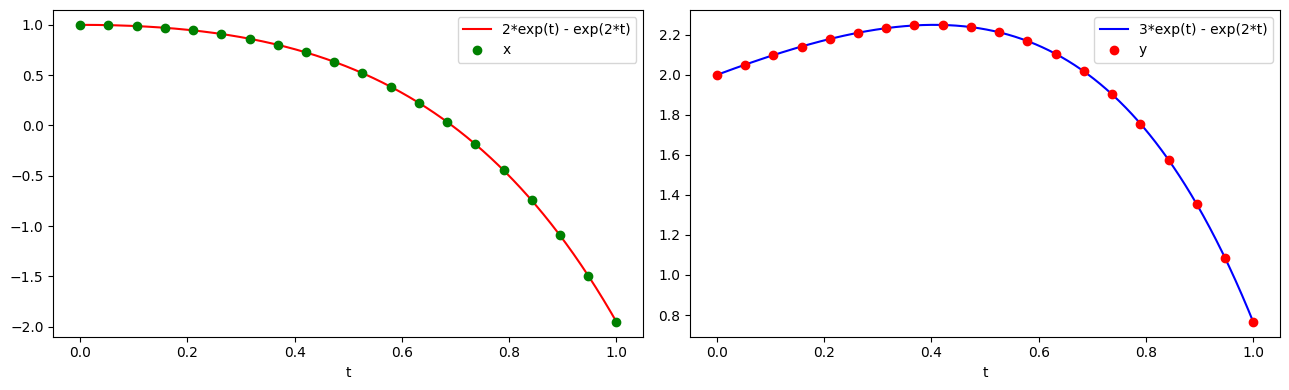

In [52]:
# 1000 smooth time points from 0 to the final simulation time
t_fine = np.linspace(0, t[-1], 1000)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
ax1.plot(
    t_fine, 2 * np.exp(t_fine) - np.exp(2 * t_fine), "r-",      # first curve: red solid line
    t_sol, x(t_sol), "go"       # second curve: green circle markers
    )
ax1.set_xlabel("t")
ax1.legend(["2*exp(t) - exp(2*t)", "x"], loc="best")

ax2.plot(
    t_fine, 3 * np.exp(t_fine) - np.exp(2 * t_fine), "b-",      # first curve: blue solid line
    t_sol, y(t_sol), "ro"       # second curve: red circle markers
    )
ax2.set_xlabel("t")
ax2.legend(["3*exp(t) - exp(2*t)", "y"], loc="best")

plt.tight_layout()
plt.show()